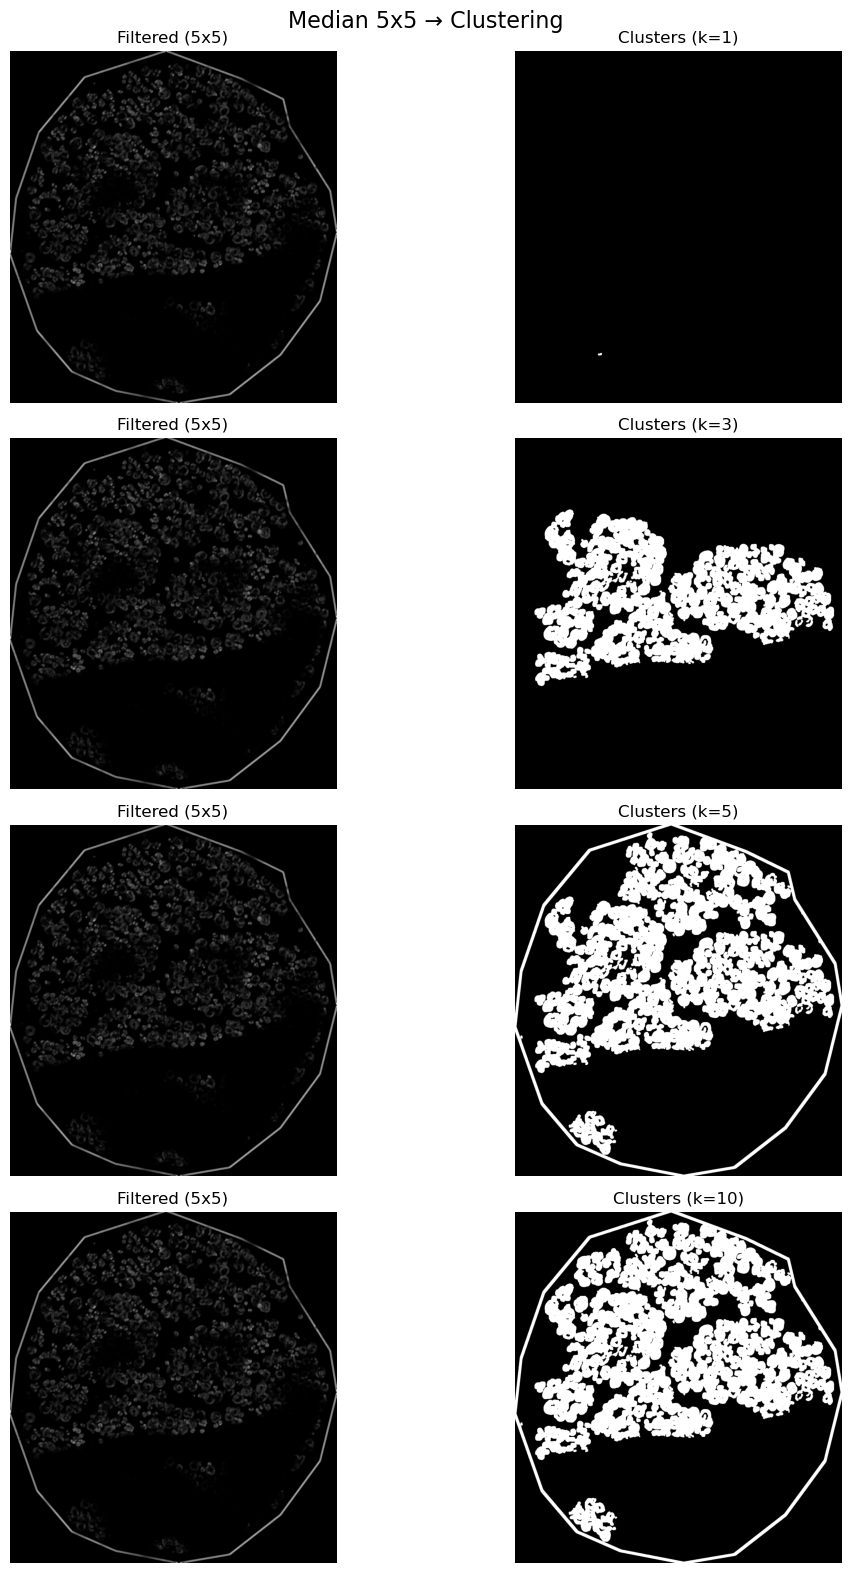

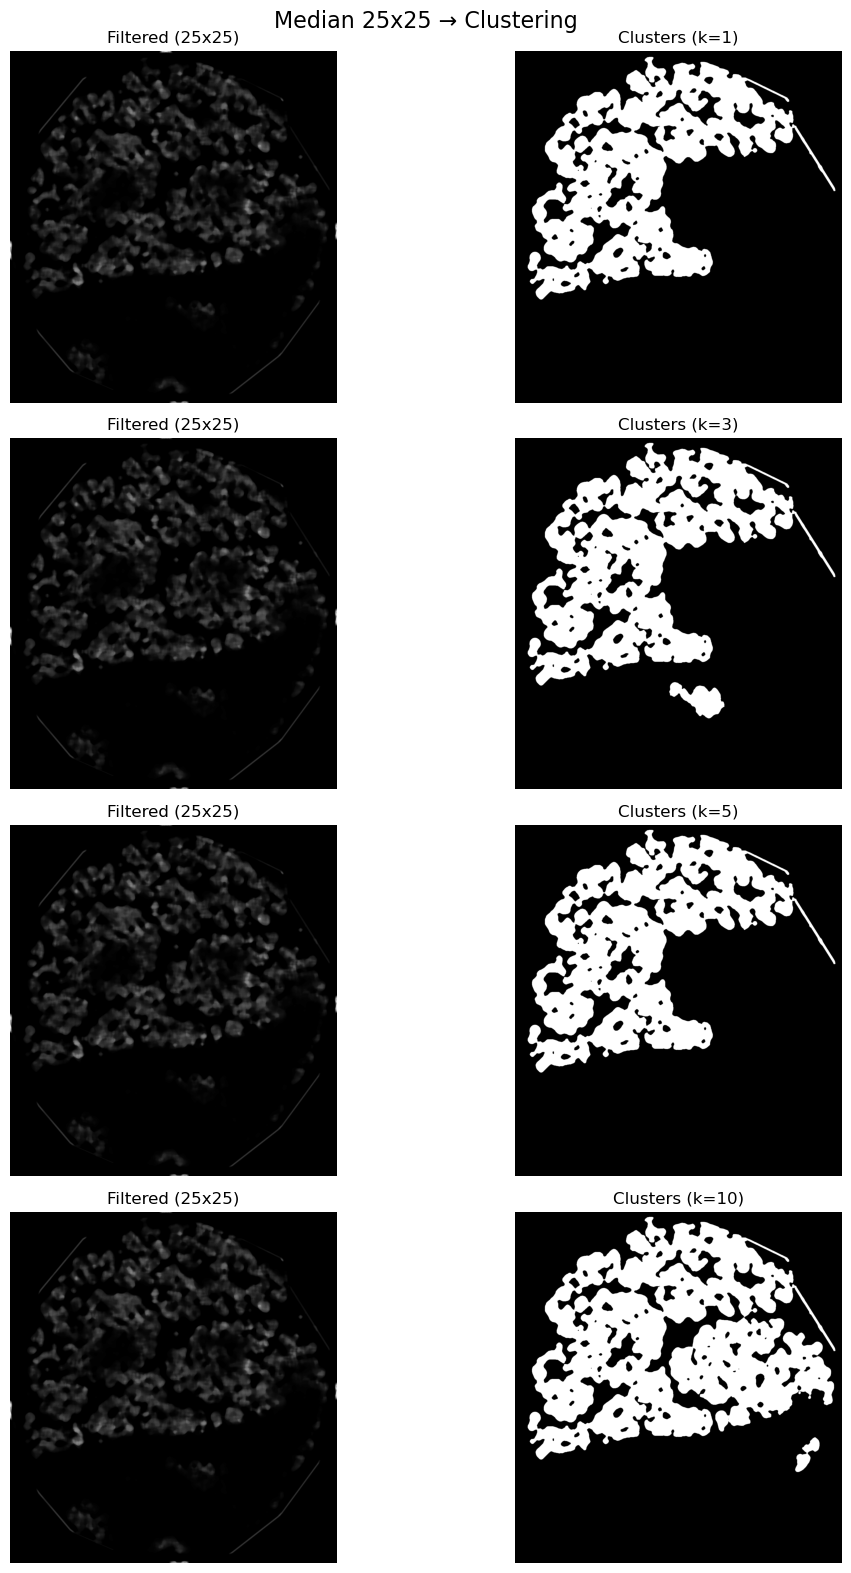

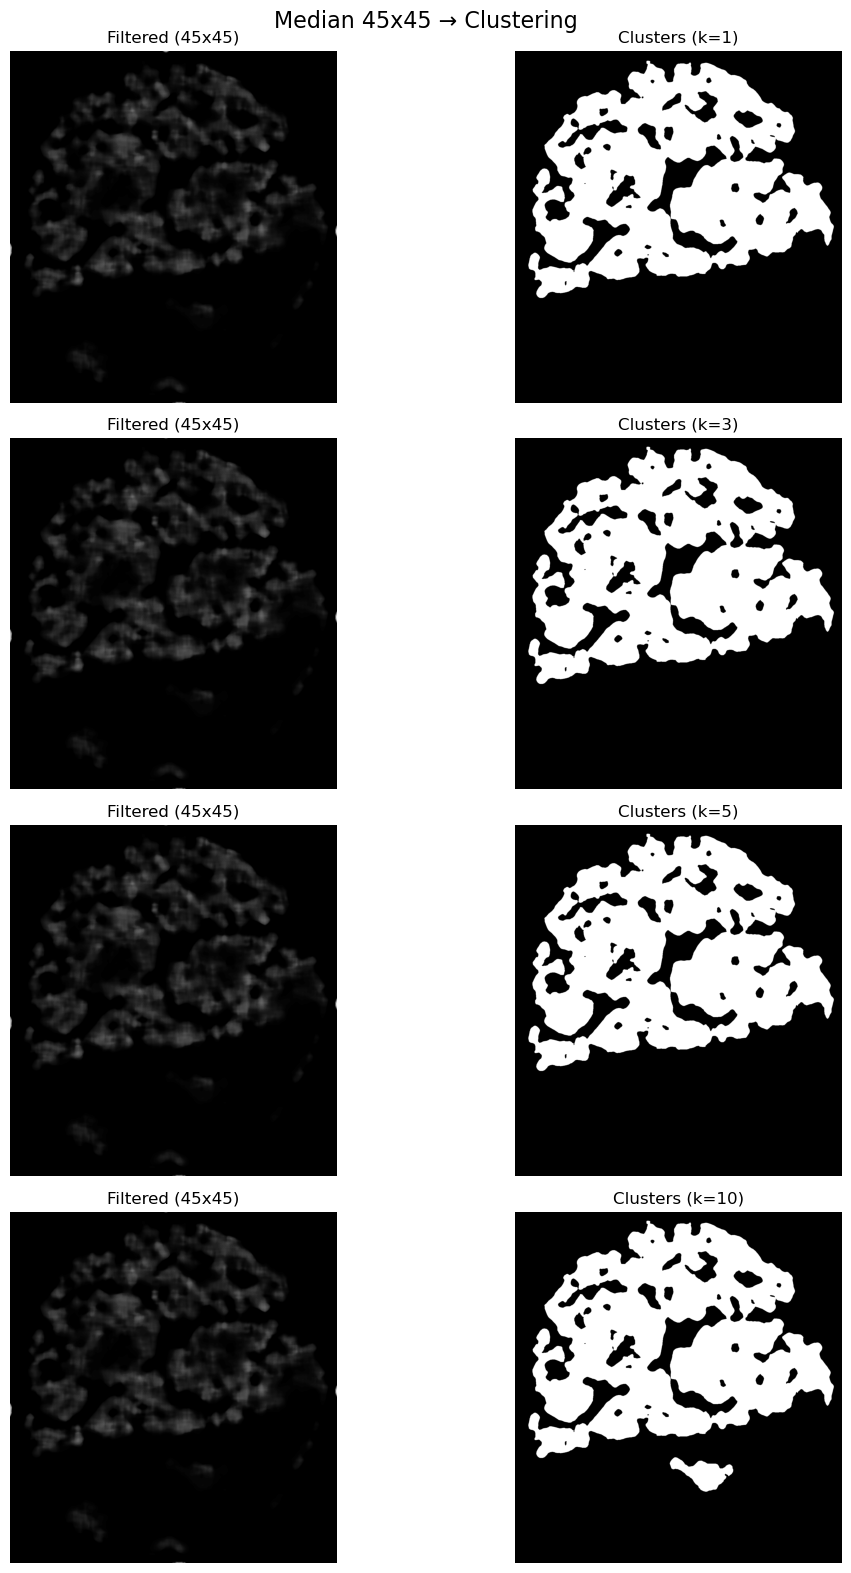

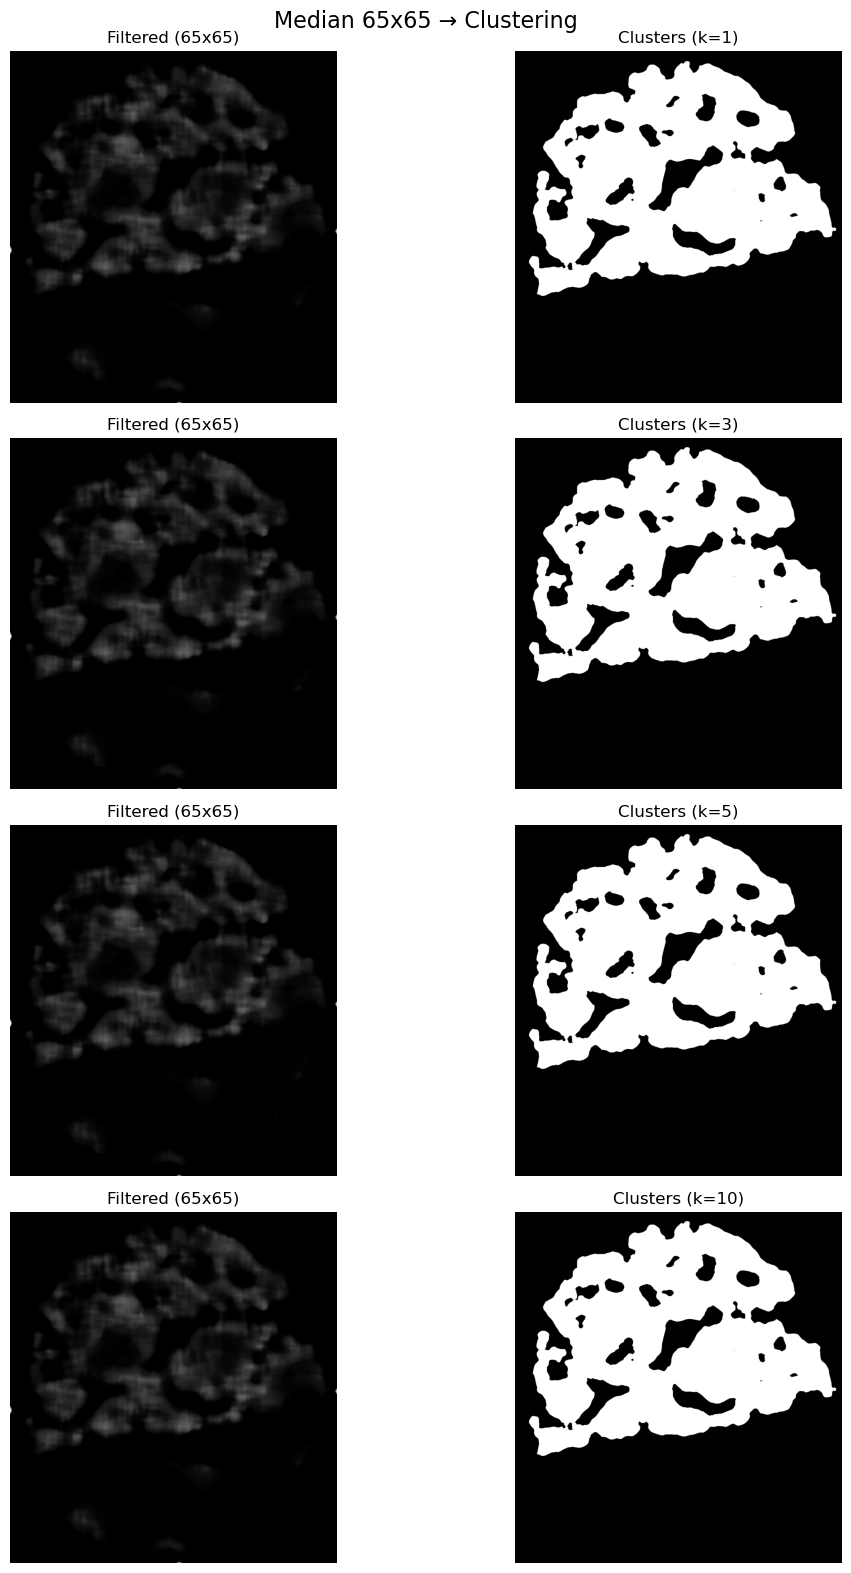

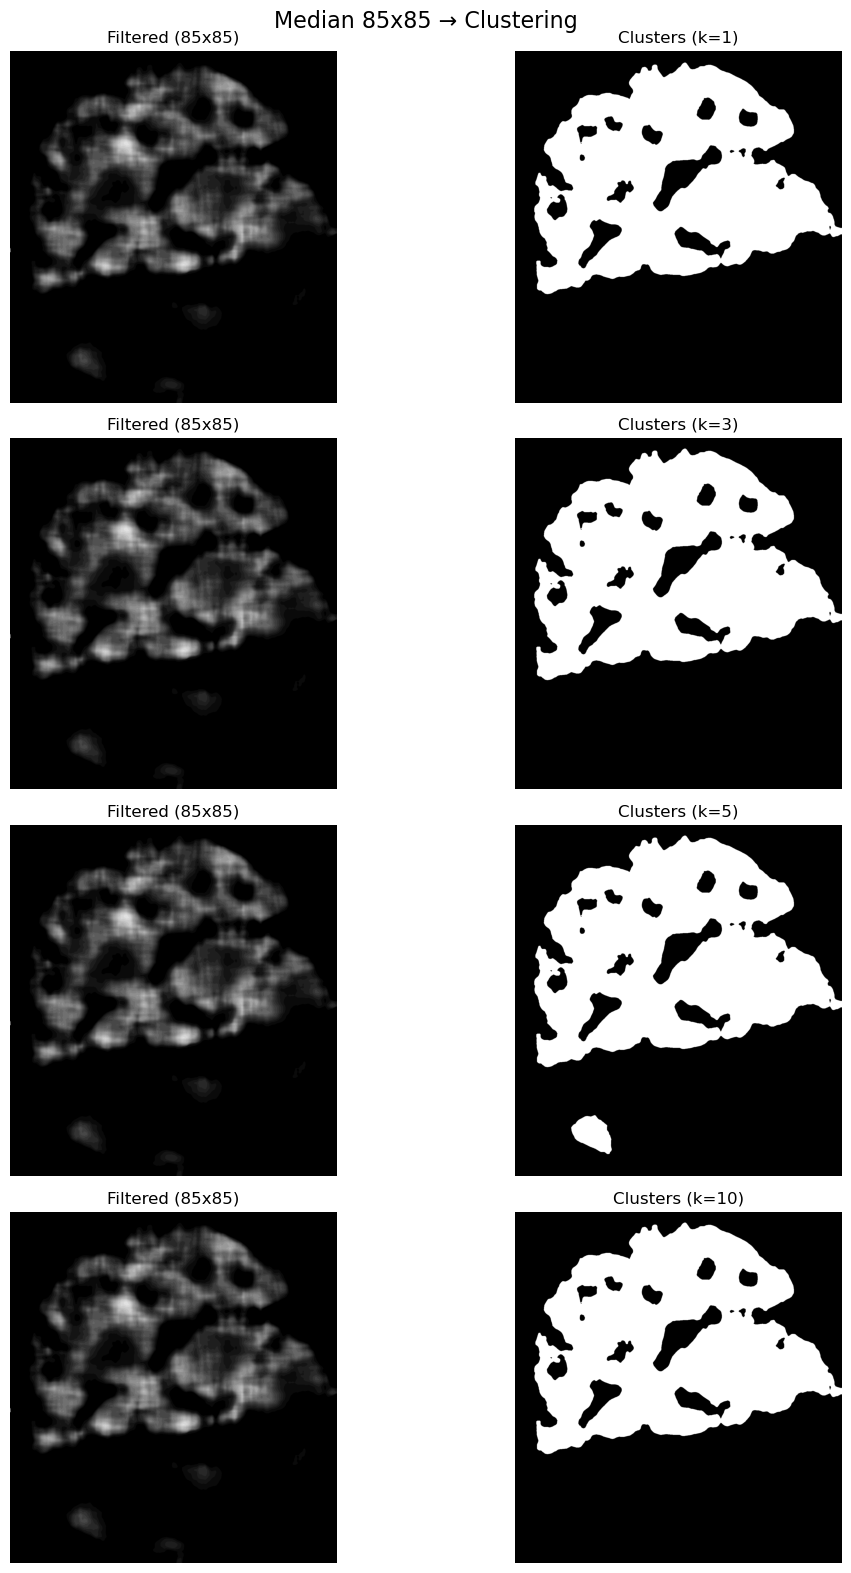

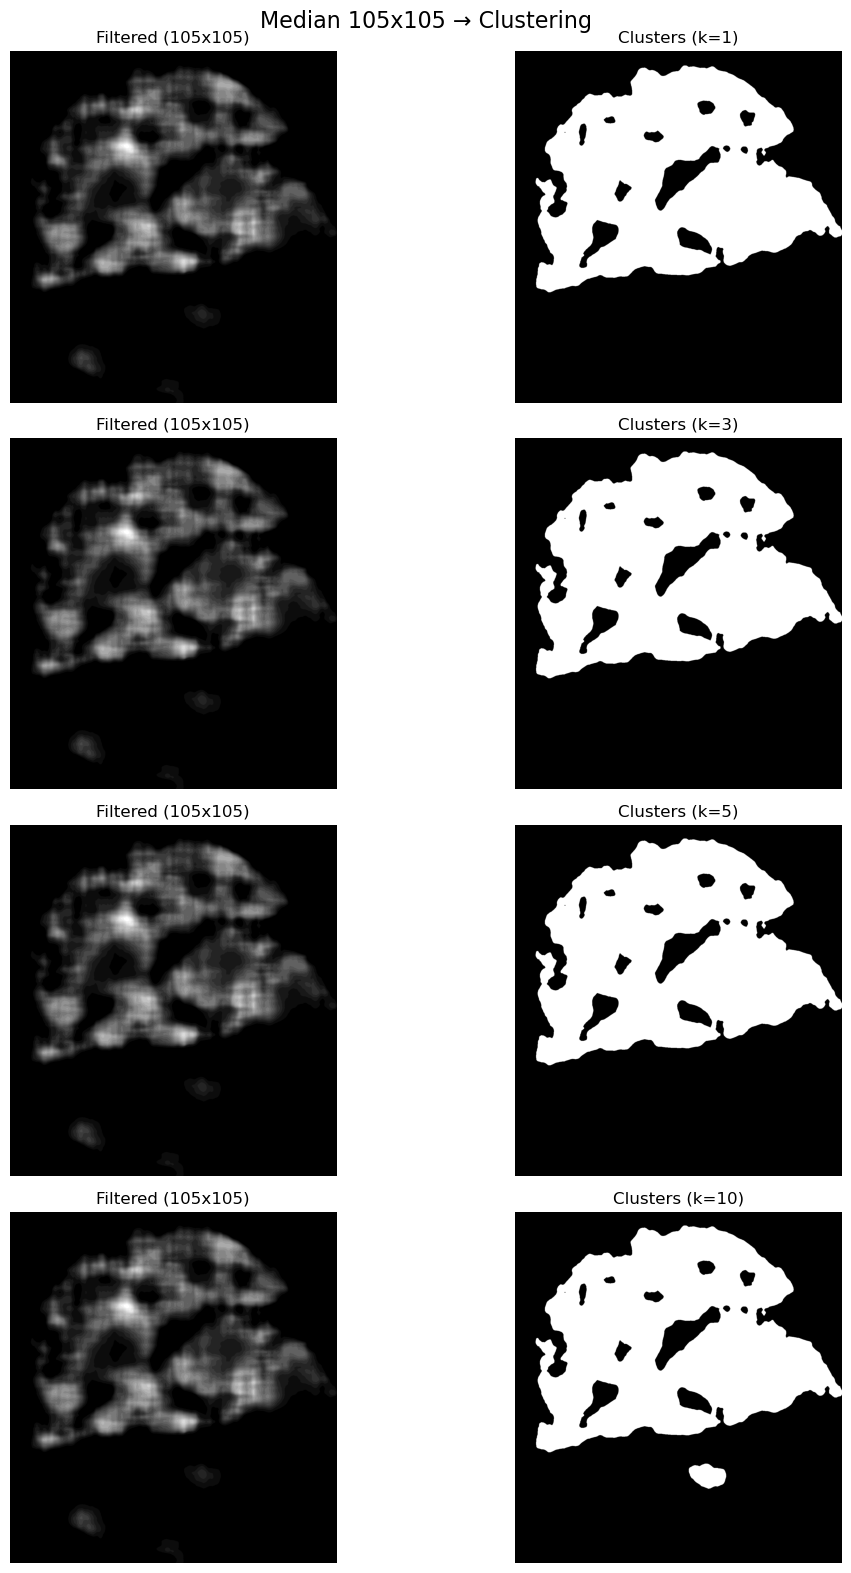

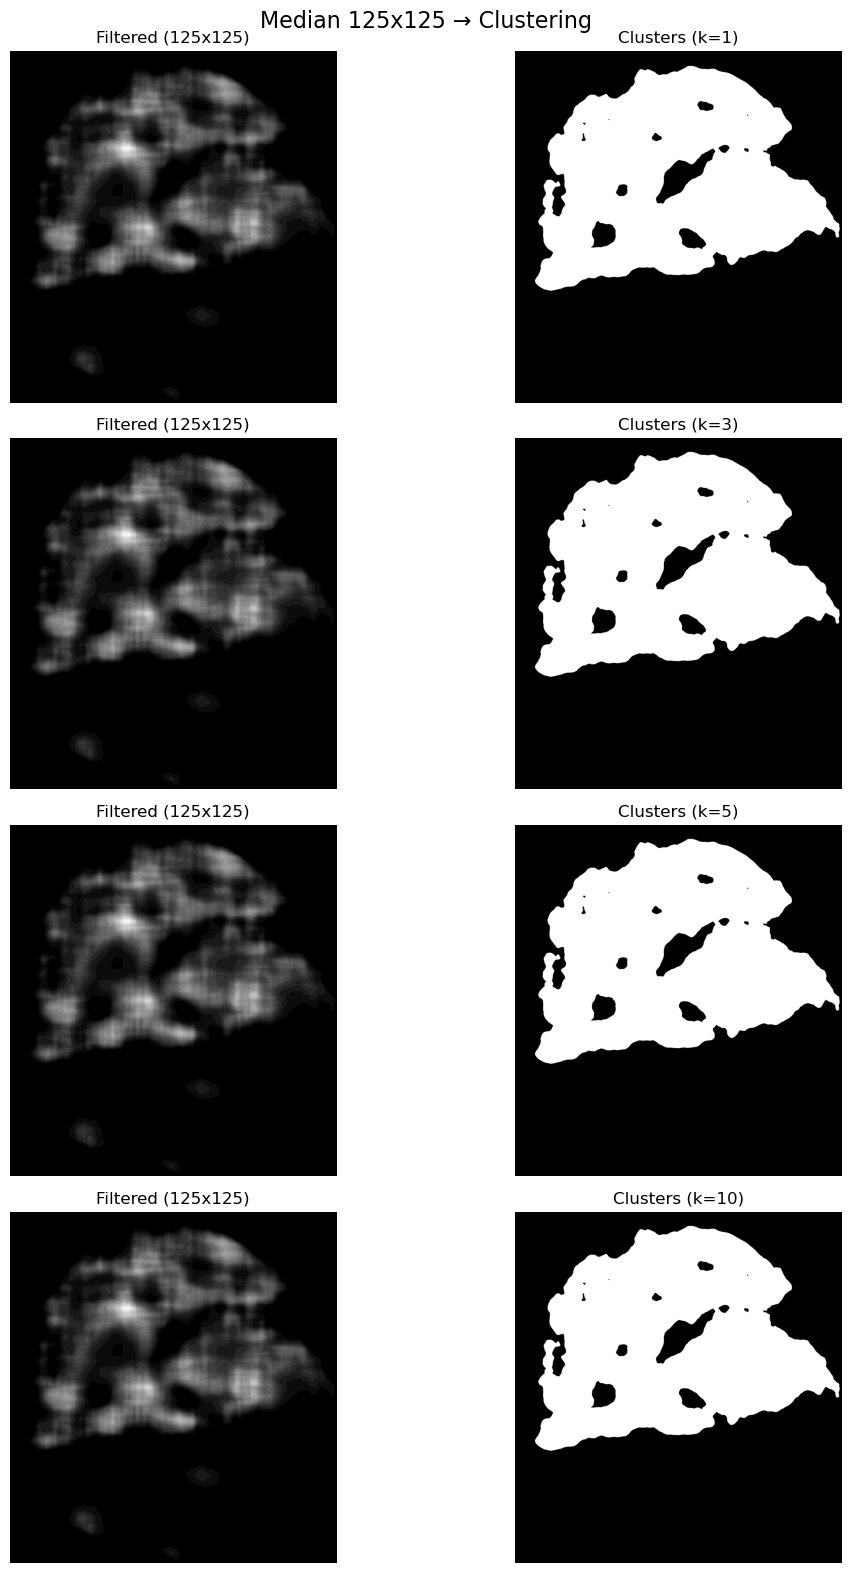

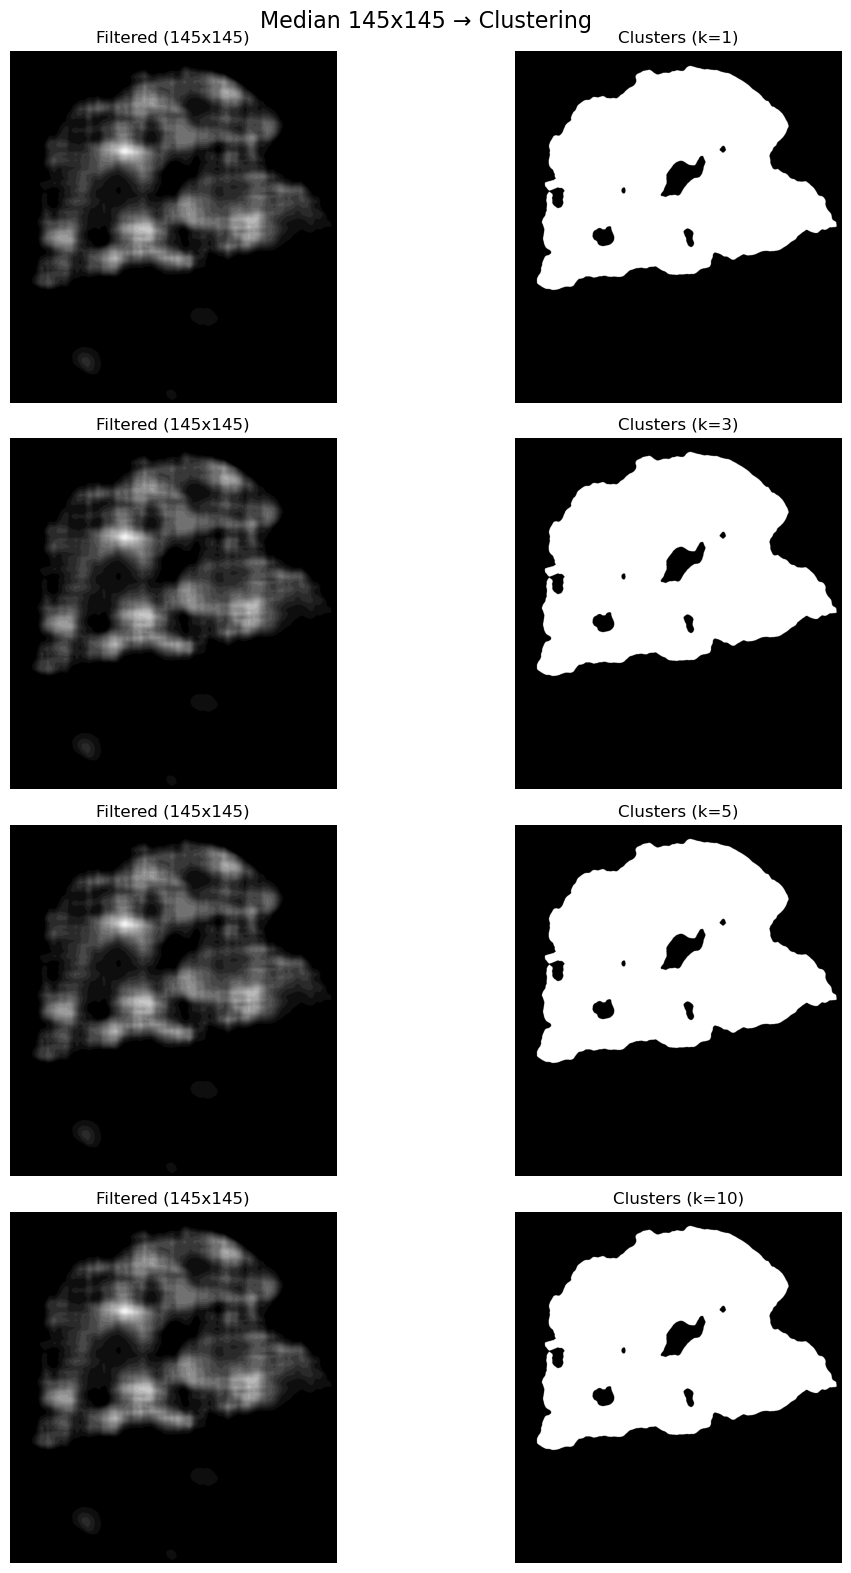

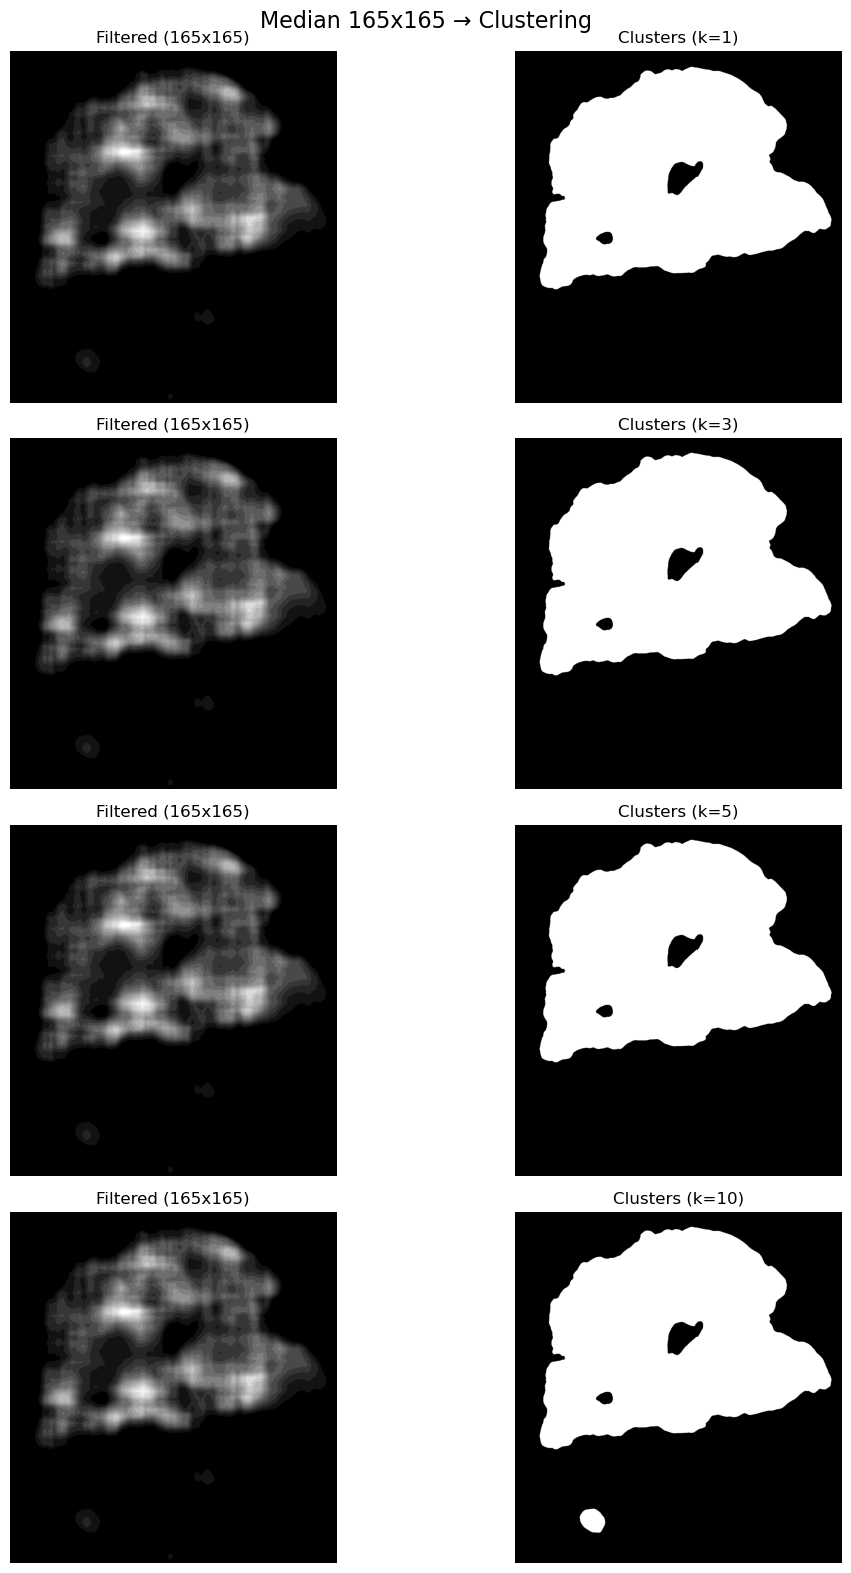

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from collections import deque

# -----------------------------
# 1. Load grayscale image
# -----------------------------
image_path = r"C:\Users\3kp05\Downloads\blur_maps_set2_Image_01_20x_bf_05_all\4\blur_map_7x7.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found. Check path.")

h, w = img.shape

# -----------------------------
# 2. Condition function
# -----------------------------
def has_nonzero_neighbor(img, x, y):
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if img[nx, ny] > 0:
                    return True
    return False


# -----------------------------
# 3. Multi-source clustering
# -----------------------------
def multi_source_clustering(img, seeds):
    labels = np.zeros((h, w), dtype=int)
    queue = deque()

    # Initialize seeds
    for i, (x, y) in enumerate(seeds):
        labels[x, y] = i + 1
        queue.append((x, y, i + 1))

    while queue:
        x, y, cid = queue.popleft()

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy

                if 0 <= nx < h and 0 <= ny < w:
                    if labels[nx, ny] == 0:
                        if img[nx, ny] > 0 or has_nonzero_neighbor(img, nx, ny):
                            labels[nx, ny] = cid
                            queue.append((nx, ny, cid))

    return labels


# -----------------------------
# 4. Parameters
# -----------------------------
k_values = [1, 3, 5, 10]
kernel_sizes = list(range(5, 166, 20))  # 5, 25, 45, ..., 165


# -----------------------------
# 5. Median BEFORE clustering
# -----------------------------
for ks in kernel_sizes:

    # Apply median filter on original blur map
    filtered_img = cv2.medianBlur(img, ks)

    # Get valid seed points
    nonzero_pixels = list(zip(*np.where(filtered_img > 0)))

    if len(nonzero_pixels) == 0:
        print(f"Skipping kernel {ks}, no non-zero pixels.")
        continue

    plt.figure(figsize=(12, 4 * len(k_values)))
    plt.suptitle(f"Median {ks}x{ks} → Clustering", fontsize=16)

    for i, k in enumerate(k_values):
        seeds = random.sample(nonzero_pixels, min(k, len(nonzero_pixels)))

        # Run clustering on filtered image
        labels = multi_source_clustering(filtered_img, seeds)

        # Convert to binary
        binary = np.zeros_like(labels, dtype=np.uint8)
        binary[labels > 0] = 255

        # Plot filtered image
        plt.subplot(len(k_values), 2, 2*i + 1)
        plt.title(f"Filtered ({ks}x{ks})")
        plt.imshow(filtered_img, cmap='gray')
        plt.axis("off")

        # Plot clustering result
        plt.subplot(len(k_values), 2, 2*i + 2)
        plt.title(f"Clusters (k={k})")
        plt.imshow(binary, cmap='gray')
        plt.axis("off")

    plt.tight_layout()
    plt.show()